<a href="https://colab.research.google.com/github/NMAURA/Inform-tica/blob/main/WineQuality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

# metadata
print(wine_quality.metadata)

# variable information
print(wine_quality.variables)


{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

### Linear Regression of Features vs. Quality for Red Wine

I will now filter the dataset to include only 'red wine' samples and then visualize the relationship between each physicochemical feature and the red wine quality using scatter plots with a linear regression line.

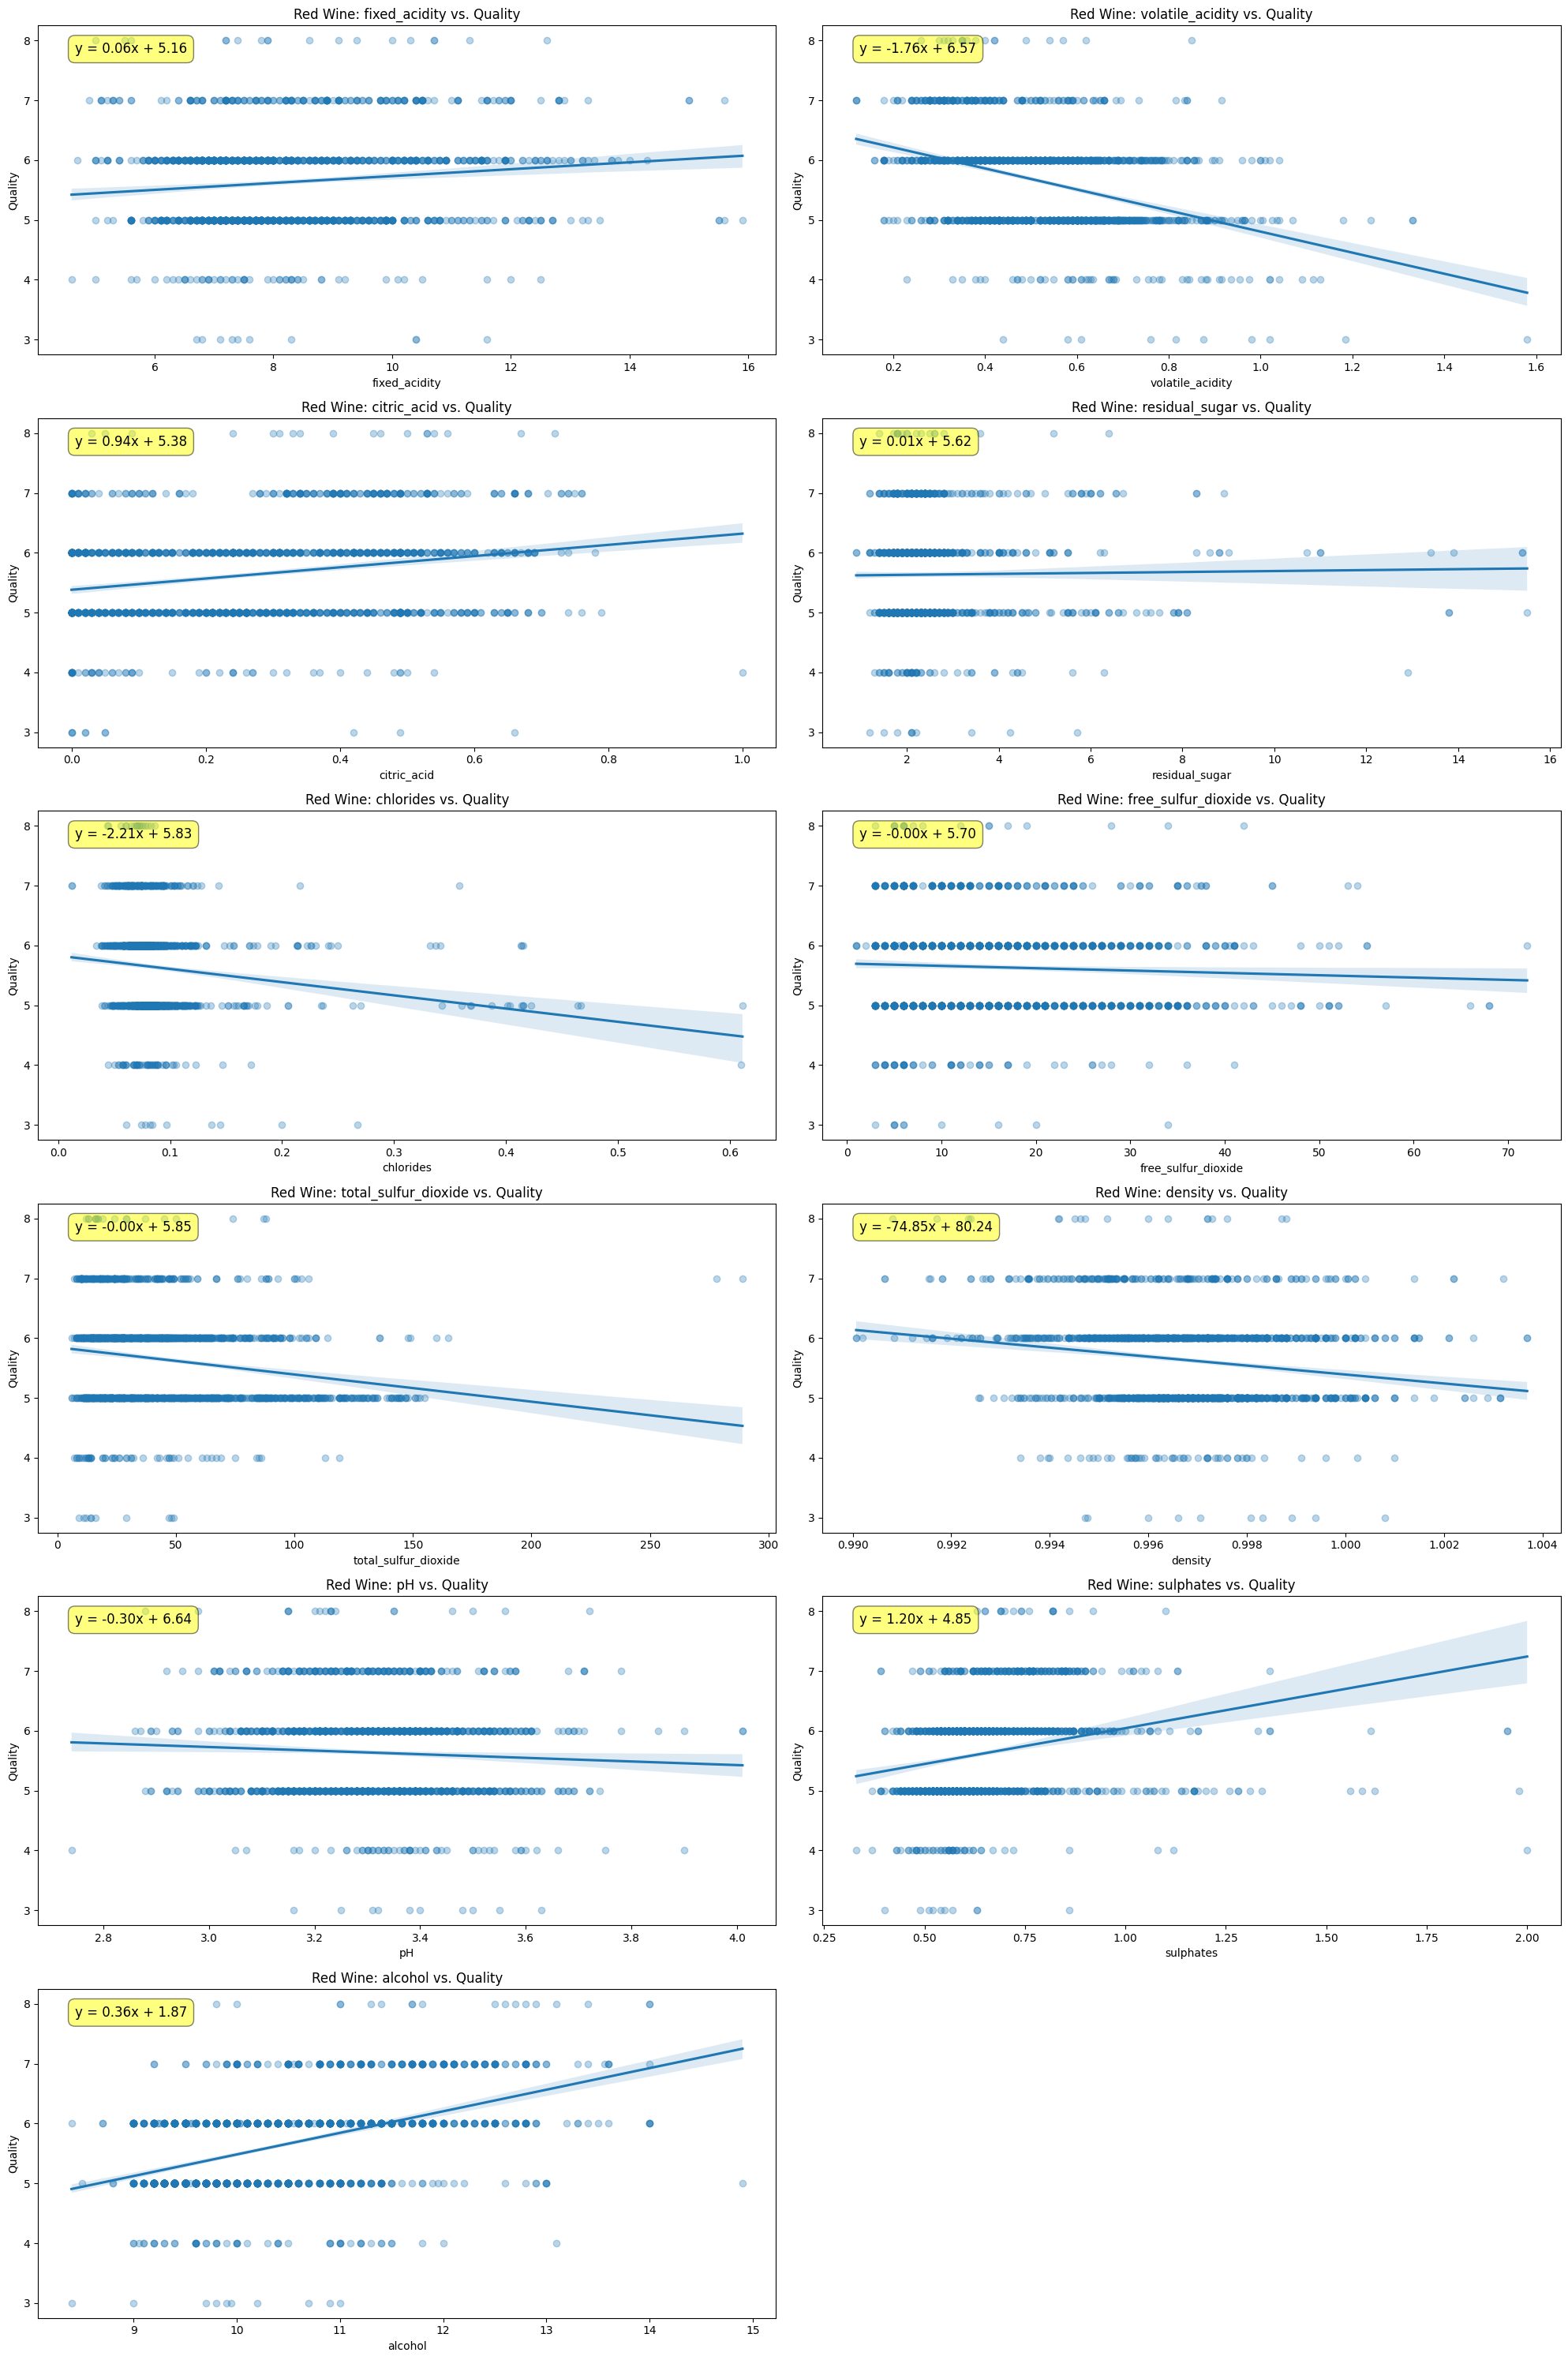

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import linregress

# Get the original dataset which includes all columns including 'type'
df_original = wine_quality.data.original

# Create a list of all column names
all_column_names = list(X.columns) + [y.columns[0], 'type']

# Assign these names to df_original
df_original.columns = all_column_names

# Filter for red wine samples
df_red_wine = df_original[df_original['type'] == 'red']

# Separate features (X_red) and target (y_red) for red wine
X_red = df_red_wine.drop(columns=['quality', 'type'])
y_red = df_red_wine['quality']

# Combine features and target into a single DataFrame for plotting
df_combined_red = pd.concat([X_red, y_red], axis=1)

# Get the list of feature columns for red wine
feature_columns_red = X_red.columns

# Create a figure to hold all plots
plt.figure(figsize=(20, 30)) # Adjust figure size to accommodate 11 plots

# Loop through each feature and create a regression plot for red wine
for i, feature in enumerate(feature_columns_red):
    plt.subplot(6, 2, i + 1) # Create a subplot for each feature (6 rows, 2 columns)
    sns.regplot(x=feature, y='quality', data=df_combined_red, scatter_kws={'alpha':0.3})
    plt.title(f'Red Wine: {feature} vs. Quality')
    plt.xlabel(feature)
    plt.ylabel('Quality')

    # Calculate linear regression equation
    slope, intercept, r_value, p_value, std_err = linregress(df_combined_red[feature], df_combined_red['quality'])
    equation = f'y = {slope:.2f}x + {intercept:.2f}'

    # Add the equation to the plot
    plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()